# Tutorial: FRET correction factors

Computing the true FRET efficiency requires characterizing the setup for 
spectral cross-talk and relative detection efficiecies of each channel.
There are several methods for this, some which require additional measurements,
some also rely on comparing lifetimes with intensities.

The `smf.fretfactory` module implements some functions that utilize the method
described in [Hellenkamp et. al.](https://doi.org/10.1038/s41592-018-0085-0).
This paper has become the general standard in the field.

> **Note**
> 
> See the
> [Full Bursts Tutorial](BurstsTutorial.ipynb#Correction-Factors)
> for an explanation of this process that does not use the `smf.fretfactory` module.

First lets import the standard modules:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, least_squares, curve_fit

import smfbursts as smf
import smfbursts.datamodel.multifit as smfit

Then load our data:

In [2]:
raw = smf.photonHDF5.load('data/dsdna_d7_d17_50_50_1.hdf5')
data = smf.photonHDF5.regularize_dets(raw)

## Description of correction factors

*Hellenkamp et. el.* defines 4 correction factors, 
2 can be classified as spectral cross-talk : $\alpha$ and $\delta$
and the other 2 as detection efficeincy: $\gamma$ and $\beta$.


### Mathematical description

Spectral cross-talk parameters are applied as "subtractive" factors, in that they represent
the amount of light from one channel that shows up in another.
$\alpha$ (also called leakage) is the amount of donor light that "leaks" into the acceptor (FRET) channel.
$\delta$ (also called direct excitation), is the amount of the acceptor that is directly excited by the donor laser.
While the origin is different, correction is done in the same way: subtract from the acceptor (FRET) channel the
predicted intensity based on the intensity of the "reference" channel (either donor emission or acceptor excitation).

Cross-section parameters are "multiplicative" factors, meaning they are factors that are used to scale
the value of a given channel to account for differing detection likelihoods.
$\gamma$ is applied to the donor channel, while $\beta$ is applied to the acceptor excitation channel.

Thus fully corrected intensities are defined as follows:

$^{iii}I_{DexAem} = ^{ii}I_{DexAem} - \alpha ^{ii}I_{DexDem} - \delta ^{ii}I_{AexAem}$

$^{iii}I_{DexDem} = \gamma ^{ii}I_{DexDem}$

$^{iii}I_{AexAem} = ^{ii}I_{AexAem}/\beta$

It should be noted that $\gamma$ and $\beta$ can be interpreted as follows:

$\gamma = \frac{g_{DexRem} ^{eff}\Phi_{F,A}}{g_{DexGem} ^{eff}\Phi_{F,D}}$

$\beta = \frac{\sigma_{AexRem} I_{Aex}}{\sigma_{DexGem} I_{Dex}}$

Where $g$ indicates detection efficeincy, $\sigma$ the excitation cross section.
$G$ and $R$ indicate emission from donor (green) or acceptor (red),
as opposed to detection(compared with $D$/$A$ indicating the observed channel).
$^{eff}\Phi_{F}$ is effective quantum yield, that is the quantum yield scaled by the fraction of excited molecules.


#### Equations for computing cross-talk factors

Where $^{ii}I$ indicates the background corrected intensity and $^{iii}I$ the corrected intensity of the channel indicated in the subscript.

The spectral cross-talk factors are computed together, and before the cross talk parameters.

The determination of the cross-talk parameters is done by characterizing the donor-only and acceptor-only burst populations.

$\alpha = \frac{\langle ^{ii}E^{DO}_{app}\rangle}{1-\langle ^{ii}E^{DO}_{app}\rangle}$

$\delta = \frac{\langle ^{ii}S^{AO}_{app}\rangle}{1-\langle ^{ii}S^{AO}_{app}\rangle}$

Where 

$^{ii}E = \frac{^{ii}I_{DexAem}}{^{ii}I_{DexAem} + ^{ii}I_{DexDem}}$ 

$^{ii}S = \frac{^{ii}I_{DexDem}+^{ii}I_{DexAem}}{^{ii}I_{DexAem} + ^{ii}I_{DexDem}+^{ii}I_{AexAem}}$

and $\langle \rangle$ indicates mean value, and the subscripts $DO$ and $AO$ indicate donor-only and acceptor only subpopulations respectively.

#### Equations for computing cross-section factors

Once the $\alpha$ and $\delta$ factors have been computed, the fully corrected $^{iii}I_{DexAem}$ value can be computed,
but the $\gamma$ and $\beta$ factors are still unknown, and thus $^{iii}I_{DexDem}$ and $^{iii}I_{AexAem}$ cannot be computed yet.

To compute these factors, at least 2 points are needed to fit the line:

$^{iii}S_{app}^{(FRET)} = (1+\gamma\beta+(1-\gamma)\beta(^{iii}E_{app}^{(FRET)})))^{-1}$

Where

$^{iii}E_{app}^{(FRET)} = \frac{^{iii}I_{DexAem}}{^{ii}I_{DexAem} + ^{iii}I_{DexAem}}$

$^{iii}S_{app}^{(FRET)} = \frac{^{ii}I_{DexAem} + ^{iii}I_{DexAem}}{^{ii}I_{DexAem} + ^{iii}I_{DexAem}+ ^{ii}I_{AexAem}}$

Where the superscript $FRET$ indicates bursts with an (single) active donor and an (single) active acceptor, 
ie those capable of undergoing FRET if the donor and acceptor are close enough.
Note that in the above definitions, the only change from the previous definitions is exchanged the $I_{DexAem}$ channel superscript from $ii$ to $iii$,
ie replacing the background corrected value with the fully corrected value.

Also note that this defninition assumes single labeling.
In most experimental designs, a single donor and 2 acceptor or other combination that is not 1 to 1 is not possible.
However, if such a combination is possible, this must be taken into account, and such populations excluded.

## Computing Correction Factors (Single burst search)

In *Hellenkamp et. el.*, they describe the process in what is equivalent to a single burst search, and distinct gates for the DO and AO populations.

### Step 1: Computing cross-talk

The first step is to isolate the donor-only and acceptor only populations.

Below we make and plot such a selection

(<matplotlib.collections.PolyCollection at 0x713e68d48bc0>,
 Text(0.5, 0, '$^{ii}E_{app}$'),
 Text(0, 0.5, '$^{ii}S_{app}$'))

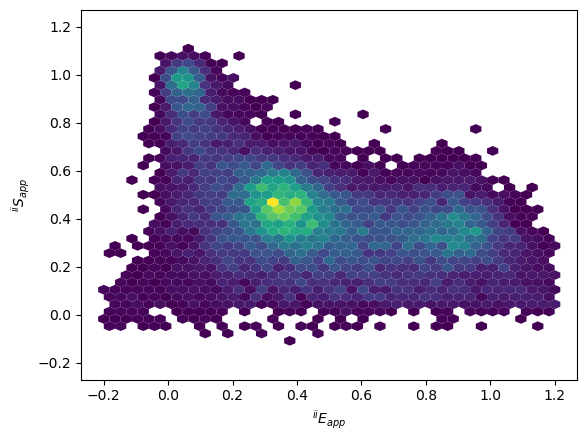

In [3]:
dbg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, auto_threshold=True, tail_min=5e-4, F_bg=2.0)
dbs = smf.fretfactory.make_burst_search(bg=dbg['bg'], streams=smf.PhSel('0ex_1ex1em'), m=10, F=6.0)
gate = smf.make_geq_gate(dbs['NphAll_bg'], 40.0)

smf.plot.hexbin(data, dbs['E_bg'], dbs['S_bg'], gate=gate, **smf.fretfactory.ALEXdefaults['hexbin'])

Now that the "full" population of bursts is visualized, 
we should decide on appropriate threshold in `S_bg` isolate the Donor only and Acceptor only subpopulations.

It is often good to visualize the gate by placing horizontal `ax.axhline()`.

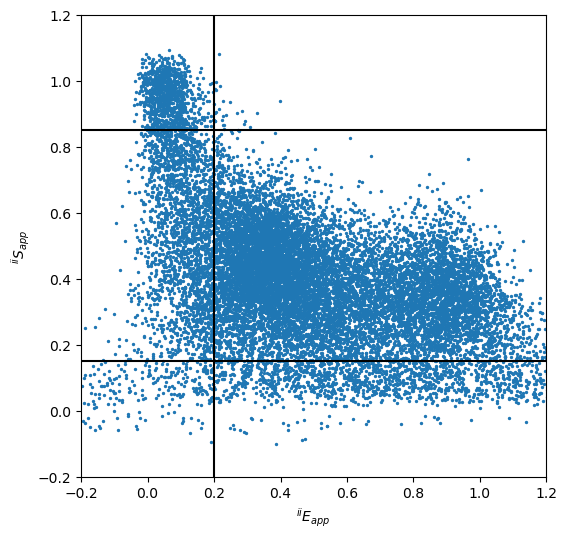

In [4]:
DO_thresh = 0.85
DO_ethresh = 0.2
AO_thresh = 0.15

fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, dbs['E_bg'], dbs['S_bg'], gate=gate, ax=ax, **smf.fretfactory.ALEXdefaults['scatter'])
ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2])
ax.axhline(DO_thresh, c='k')
ax.axhline(AO_thresh, c='k')
ax.axvline(DO_ethresh, c='k')

Once the DO and AO thresholds are set appropriately, proceed to make the gates.

Then the function `smf.fretfactory.crosstalk_correction` can be used to compute the appropriate correction factor.
It is also generally recomended to set a minimum counts in the important intensity channel to ensure each burst has a legible intensity.

Make sure the correctly assign the gates and columns, a mix-up will result in a completely incorrect factor being computed.

In general the values of $\alpha$ and $\delta$ should be positive and close to 0.

In [5]:
gateDO = gate & smf.make_geq_gate(dbs['S_bg'], DO_thresh) & smf.make_lt_gate(dbs['E_bg'], DO_ethresh) & smf.make_geq_gate(dbs['NphDex_bg'], 30.0) 
gateAO = gate & smf.make_lt_gate(dbs['S_bg'], AO_thresh) & smf.make_geq_gate(dbs['NphAA_bg'], 30.0)

alpha = smf.fretfactory.crosstalk_correction(data, dbs['E_bg'], gate=gateDO) # leakage
delta = smf.fretfactory.crosstalk_correction(data, dbs['S_bg'], gate=gateAO) # direct excitation
alpha, delta

(np.float64(0.06295260571546751), np.float64(0.08103928718800112))

Now we can create a dictionary of partially corrected ($^{iii}E_{app}$ and $^{iii}S_{app}$) columns:

In [6]:
dbs_app = smf.fretfactory.make_correction_factors(dbs['nphbg'], alpha=alpha, delta=delta)

And finally to check that the correction factors are reasonable, we make an E-S plot with the newly created columns.
The DO population should be centered at $E=0$ and $S=1$, while the AO population should be centered around $S=0$.

The $DA$ (donor acceptor, which is usually FRET active) population(s) can vary in their position, but will have intermediate $^{iii}S_{app}$ values.

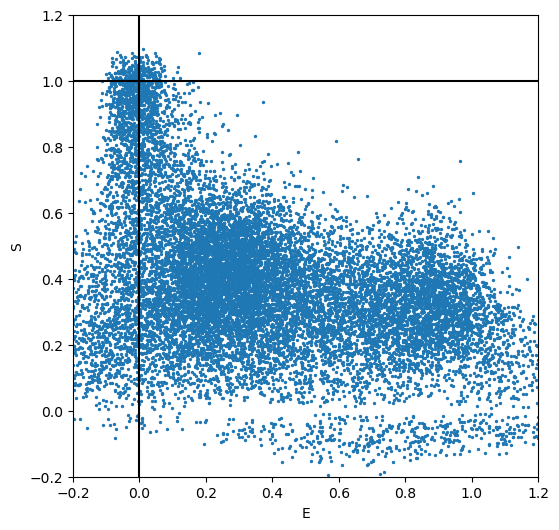

In [7]:
fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, dbs_app['E'], dbs_app['S'], gate=gate, **smf.fretfactory.ALEXdefaults['scatter'], ax=ax)
ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2])
ax.axvline(0, c='k')
ax.axhline(1, c='k')

### Cross-section corrected values

Now that the cross-talk values have been computed, 
we can isolate the donor acceptor ($DA$) population, and compute the cross-section related parameters.

The basic method is to optimize the parameters $\gamma$ and $\beta$ to the equation:

$^{iii}S_{app}^{DA} = (1+\gamma\beta+(1-\gamma)\beta ^{iii}E_{app}^{DA})^{-1}$

This can be done burst-wise, or population by population.

*Hellenkamp et. al.* shows that the above equation is equivalent to solving for the slope $a$ and intercept $b$
of the line of the points $[(^{iii}E_{app}^{DA})^{-1}, (^{iii}S_{app}^{DA})^{-1}]$.
**Note that this is the line of the *inverses* of the standard values**,
$a$ and $b$ are related to $\gamma$ and $beta$ by the following equations

$\gamma = (a-1) / (a + b -1)$

$\beta = a + b - 1$

#### Global population fit

First, we want to decide on a gate to isolate the FRET active population.
This is typically done by setting thresholds for the partially corrected $^{iii}E_{app}$ and $^{iii}S_{app}$ values.
To visually see the thresholds, as before, it is recomended to plot with lines set by `ax.axhline()`.

(-0.2, 1.2)

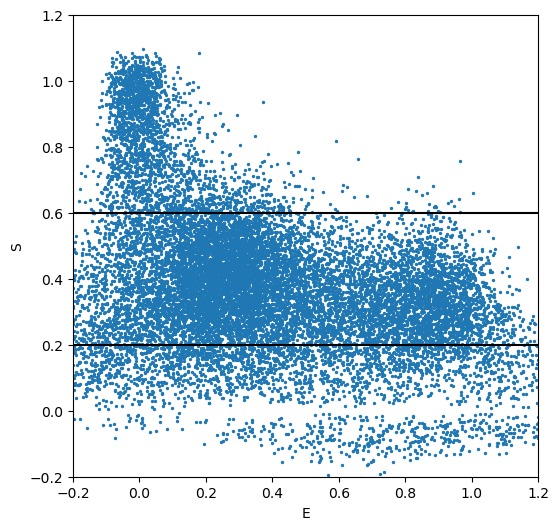

In [8]:
lfret_thresh = 0.2
hfret_thresh = 0.6

fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, dbs_app['E'], dbs_app['S'], gate=gate, ax=ax, **smf.fretfactory.ALEXdefaults['scatter'])
ax.axhline(lfret_thresh, c='k')
ax.axhline(hfret_thresh, c='k')
ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2])

Now we can compute the gamma and beta values using `smf.fretfactory.gamma_beta_global`.

First we make a gate for the FRET population using our determined thresholds, and then hand the
cross-talk corrected `E` and `S` columns to `smf.fretfactory.gamma_beta_global`, with the gate,
and it will perform a least-squares optimization to fit the preveously described equiation from *Hellenkamp et. al.*.

In [9]:
gateFRET = gate & smf.make_geq_gate(dbs_app['S'], lfret_thresh) & smf.make_lt_gate(dbs_app['S'], hfret_thresh)

gamma_glob, beta_glob = smf.fretfactory.gamma_beta_bursts(data, dbs_app['E'], dbs_app['S'], gate=gateFRET, fit_func=smf.fretfactory.gamma_beta_fitdirectvals)
gamma_glob, beta_glob

(np.float64(0.8001448287381707), np.float64(1.8770750099066358))

Now we can make the fully corrected values:

In [10]:
dbs_glob = smf.fretfactory.make_correction_factors(dbs['nphbg'], alpha=alpha, delta=delta, gamma=gamma_glob, beta=beta_glob)

and plot the results

(-0.2, 1.2)

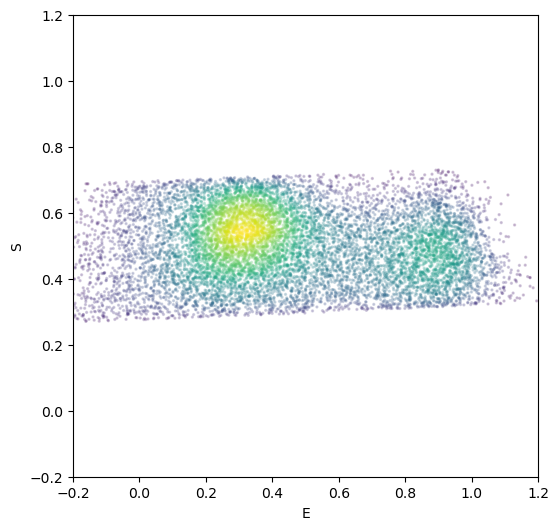

In [11]:
fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, dbs_glob['E'], dbs_glob['S'], gate=gateFRET, ax=ax, 
                 point_func=smf.plot.density_kde, alpha=0.2, **smf.fretfactory.ALEXdefaults['scatter'])
ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2])

#### 2 center fit

Another method is to fit 2 or more of the FRET populations, and use the centers of the populations to compute a fit line of the population centers.

To do this, we can use the [MultiFit modeule](MultiFitTutorial.ipynb) to fit the locations of the populations.

> **Note**
>
> This requires the subpopulations to be fittable.
> Within burst dynamics can interfere with this.

In [12]:
# initial guesses for centers and widths of distributions
mu = np.array([[0.1, 0.5],  # guess of  E S population 1
               [0.7, 0.5]]) # guess of ES population 2
sigma = np.array([[[0.01, 0.0],[0.0, 0.01]], # population 1 sigma
                  [[0.01, 0.0],[0.0, 0.01]]]) # population 2 sigma

init_fret = smfit.make_nd_init(smfit.ndgaus_pdf, sigma=sigma, mu=mu)

# make multi-dimentional mu and sigma arrays for bounds
mu_b = np.array([[[0.0, 0.0], [1.0, 1.0]],
                 [[0.0, 0.0], [1.0, 1.0]]])
sigma_b = np.array([[[[1e-8, -1e-8],[-1e-8, 1e-8]], # lower bounds dist 1
                     [[0.04, 1e-4],[1e-4, 0.04]]], # upper bounds dist 1
                    [[[1e-8, -1e-4],[-1e-4, 1e-8]], # lower bounds dist 2
                     [[0.04, 1e-4],[1e-4, 0.04]]]]) # uper bounds dist 2
bounds = smfit.make_nd_bounds(smfit.ndgaus_cdf, mu_b, sigma_b)


res_2pop = smfit.fit_column_mle(data, (dbs_app['E'], dbs_app['S']), smfit.ndgaus_pdf, init_fret, gate=gateFRET, bounds=bounds)
params_2pop = smfit.unwrap_nd_param(smfit.ndgaus_pdf, 2, res_2pop.x)
params_2pop

{'mu': [array([0.24586234, 0.39260237]), array([0.83995083, 0.33722515])],
 'sigma': [array([[0.03882451, 0.0001    ],
         [0.0001    , 0.01069415]]),
  array([[ 0.01933614, -0.0001    ],
         [-0.0001    ,  0.00758427]])],
 'amps': array([0.72249222, 0.27750778])}

Now we plot the fit to ensure it makes sense:

(-0.1, 1.1)

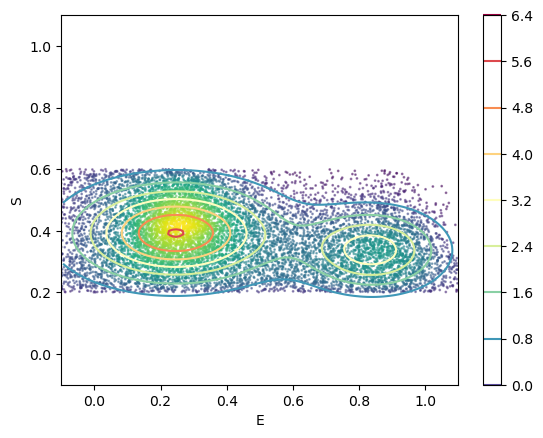

In [13]:
# plot
locs = np.linspace(-0.1,1.1, 120)
mid_locs = locs[:-1] + np.diff(locs)/2
blocs = np.stack(np.meshgrid(mid_locs, mid_locs), axis=-1)
plt.contour(mid_locs, mid_locs, smfit.ndgaus_pdf(res_2pop.x, blocs), cmap='Spectral_r')

smf.plot.scatter(data, dbs_app['E'], dbs_app['S'], gate=gateFRET, s=1.0, alpha=0.5, point_func=smf.plot.density_kde)
plt.colorbar() # adds colorbar of contour plot
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1])

Finally, we can extract the E and S arrays, and use one of the
``smf.fretfactory.gamma_beta_linregressvals``, or ``smf.fretfactory.gamma_beta_fitlinearvals`` or ``smf.fretfactory.gamma_beta_fitdirectvals``
Each uses a different scipy algorithm to fit the same basic line.

In [14]:
gamma_2pop, beta_2pop, lg_2pop = smf.fretfactory.gamma_beta_linregressvals(np.asarray([mu[0] for mu in params_2pop['mu']]), np.asarray([mu[1] for mu in params_2pop['mu']]))
gamma_2pop, beta_2pop

(np.float64(0.6611958283692291), np.float64(2.078061419830789))

(-0.1, 1.1)

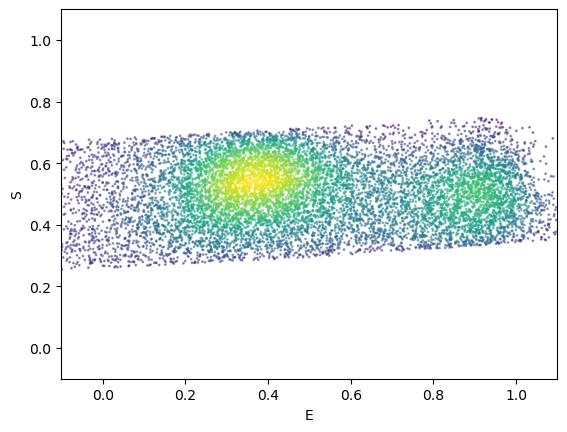

In [15]:
# make corrected values
dbs_2pop = smf.fretfactory.make_correction_factors(dbs['nphbg'], alpha=alpha, delta=delta, gamma=gamma_2pop, beta=beta_2pop)

smf.plot.scatter(data, dbs_2pop['E'], dbs_2pop['S'], gate=gateFRET, s=1.0, alpha=0.5, point_func=smf.plot.density_kde)
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1])

### Fit using DCBS

In my experience, isolatting the FRET population is easier with the DCBS algorithm.

The above examples of deriving the $\gamma$ and $\beta$ values from the FRET population have not yielded the best fits,
largely because of the number of bursts outside the expected populations.

As long as the `m` and `F` values remain the same, using DCBS generally yields comparable bursts to ACBS,
while doing a better job of removing blinking events.

In [16]:
dbs_dcbs = smf.fretfactory.make_burst_search(bg=dbg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')), alpha=alpha, delta=delta)
gate_dcbs = smf.make_geq_gate(dbs_dcbs['NphDex_bg'], 40.0) & smf.make_geq_gate(dbs_dcbs['NphDA_bg'], 30.0)

(-0.1, 1.1)

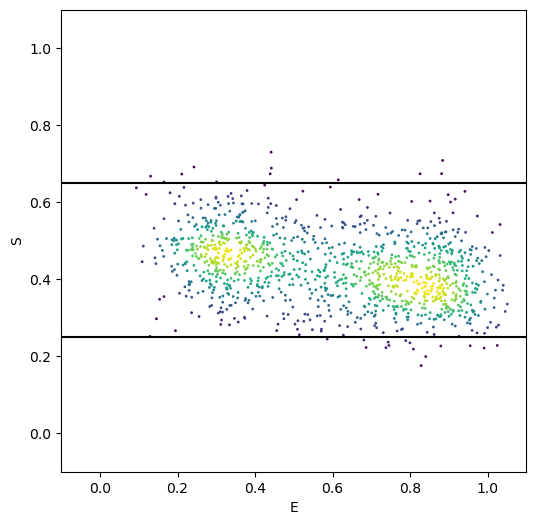

In [17]:
Shigh_thresh = 0.65
Slow_thresh = 0.25

fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, dbs_dcbs['E'], dbs_dcbs['S'], gate=gate_dcbs, ax=ax, s=1.0, point_func=smf.plot.density_kde)
ax.axhline(Shigh_thresh, c='k')
ax.axhline(Slow_thresh, c='k')
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([-0.1, 1.1])

Now we make the cross-talk corrected factors, an appropriate gate, 
and fit the bursts (any of the methods used before is applicable) to get the correction factors.

In [18]:
gate_dcFRET = gate_dcbs & smf.make_geq_gate(dbs_dcbs['S'], Slow_thresh) & smf.make_lt_gate(dbs_dcbs['S'], Shigh_thresh)

gamma_dcbs, beta_dcbs = smf.fretfactory.gamma_beta_bursts(data, dbs_dcbs['E'], dbs_dcbs['S'], gate=gate_dcFRET)
dbs_dcbs_corr = smf.fretfactory.make_correction_factors(dbs_dcbs['nphbg'], alpha=alpha, delta=delta, gamma=gamma_dcbs, beta=beta_dcbs)
gamma_dcbs, beta_dcbs

(np.float64(0.6402886292786983), np.float64(1.660994552640735))

Let's see how these correction factors look:

(-0.1, 1.1)

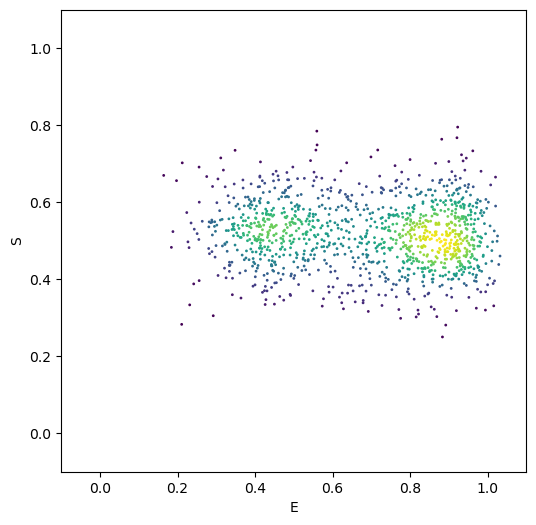

In [19]:
fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, dbs_dcbs_corr['E'], dbs_dcbs_corr['S'], gate=gate_dcbs, ax=ax, s=1.0, point_func=smf.plot.density_kde)
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([-0.1, 1.1])

These factors can be applied to the previous acbs burst search:

(-0.2, 1.2)

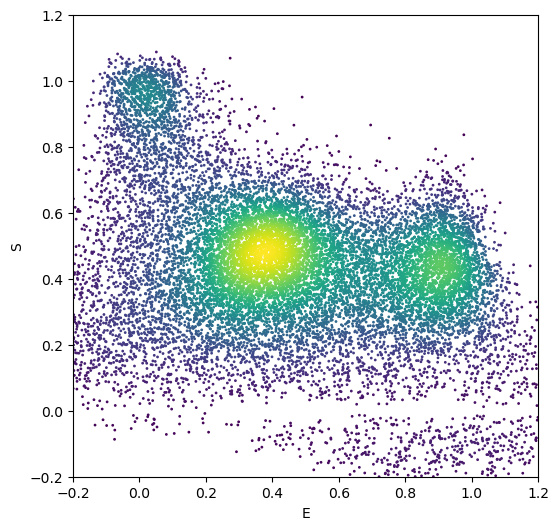

In [20]:
dbs_acbs_dccorr = smf.fretfactory.make_correction_factors(dbs['nphbg'], alpha=alpha, delta=delta, gamma=gamma_dcbs, beta=beta_dcbs)

gateEvalid = smf.make_geq_gate(dbs_acbs_dccorr['E'], -0.2) & smf.make_lt_gate(dbs_acbs_dccorr['E'], 1.2)
gateSvalid = smf.make_geq_gate(dbs_acbs_dccorr['S'], -0.2) & smf.make_lt_gate(dbs_acbs_dccorr['S'], 1.2)
gate_valid = gate & gateEvalid & gateSvalid

fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, dbs_acbs_dccorr['E'], dbs_acbs_dccorr['S'], gate=gate_valid, ax=ax, s=1.0, point_func=smf.plot.density_kde)
ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2])

## Publication Recomendations

### Citations

Of course, after we are done we should remember to print out the citations wtih `smf.print_citations()` 
(or get them with `smf.get_citations()` instead for a more detailed list)

In [21]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
3. Hellenkamp, B., Schmid, S., Doroshenko, O. et al. Precision and accuracy of
    single-molecule FRET measurements—a multi-laboratory benchmark study. Nat
    Methods 15, 669–676 (2018).
4. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).


### Print Params

It is also recomended to get descriptions of the parameters used for the analysis.

All `Param`, `Column`, and `GateGroup` objects have a `.description` property.
Printing this will generate a yaml-like string that is good to add to your supplementary data, as it exactly describes the object.

For FRET corrections, the important `Param` is the "ratios" key in the created dictionary (it has a `Param` type of `smf.Ratios`).
You may also consider the "E" or "S" `Column`, which are derived from this `Param`.

In [22]:
print("acbs burst search::")
print(dbs['bursts'].description)
print('-'*80)
print("DO gate::")
print(gateDO.description)
print('-'*80)
print("AO gate::")
print(gateAO.description)
print('-'*80)
print("apparent param::")
print(dbs_app['ratios'].description)
print('-'*80)
print('FRET gate::')
print(gate_dcFRET.description)
print('-'*80)
print("dcbs burst search::")
print(dbs_dcbs_corr['ratios'].description)
print('-'*80)

acbs burst search::
Table: Bursts
Params:
  streams: (0ex_1em)
  m: [10]
  F: [6.]
  c: [-1.]
  truthtable: [False  True]
  fuse: [0.]
  asP: [False]
Parents:
  bg:
    - Table: BG
      Params:
        compute_stream: single_all
        func: smfbursts.background.exp_mlefit
        tail_min: [0.0005 0.0005 0.0005 0.0005 0.0005]
        auto_threshold: True
        F_bg: 2.0
      Parents:
        base:
          Table: Periods
          Params:
            period: 60.0
            start_at: time_min
            stop_at: over
            detdef: DetDef2ex2em
--------------------------------------------------------------------------------
DO gate::
GateGroup:
  truthtable: [[[[[False False]
                  [False False]]
              
                 [[False False]
                  [False False]]]
              
              
                [[[False False]
                  [False False]]
              
                 [[False False]
                  [ True False]]]]
          

The above cell only uses the 2 population fit gates etc. make sure you describe the particular style of corrections you used,
and select the relevant parameters/columns/gates to include.